# Numerical solver for the discrete space and structured model

### Setup

Import the model and paramater class from the file model_solver

In [302]:
%load_ext autoreload
%autoreload 2

# Standard Imports
import numpy as np
import matplotlib.pyplot as plt
import math

# Your Custom Import
from model_solver import Params
from model_solver_nonlinear_offload import NonlinearMacrophageModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters and execution

In [474]:
# Define your parameters
p = Params(
    M=100, N=100, kplus=6, kminus=0.4, beta=0.2, D_min=0.1, gamma=0.2,
    sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=True
)

t_final = 40.0

In [475]:
# Initialize the new model with a specific nonlinear profile
model = NonlinearMacrophageModel(p, offloading_type='quartic')

# Setup Time
t_span = (0.0, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 500)
u0 = 1/(model.p.N * model.p.M) * np.ones((model.p.M + 1, model.p.N + 1))  # Initial condition: uniform distribution
y0 = u0.ravel()  # Flatten the initial condition for the solver

# Run the solver!
print("Starting solver...")
U, sol = model.solve(t_span, t_eval)
print(f"Solver finished successfully: {sol.success}")

# Extract all data
results = model.compute_diagnostics(U)

Starting solver...
Solver finished successfully: True


### Plotting and analysis

In [476]:
# Define time points to plot the results
time_points = [0.1, 0.5, 1.0, 1.5, t_final]

# 1. Choose a sequential colormap (e.g., 'Blues', 'Reds', 'Greens', 'Purples')
cmap = plt.get_cmap('Blues')

# 2. Generate the colors. 
# We map from 0.3 to 1.0 so the "lightest" color isn't completely white and invisible!
colors = cmap(np.linspace(0.3, 1.0, len(time_points)))

# Pick a few spatial points to plot
spatial_sites_to_plot = [0, int(p.M * 0.1), int(p.M * 0.25), int(p.M * 0.37), int(p.M * 0.75), p.M]
num_plots = len(spatial_sites_to_plot)

Plot $k^+_n$ and $k^-_n$ against $n$ at steady state

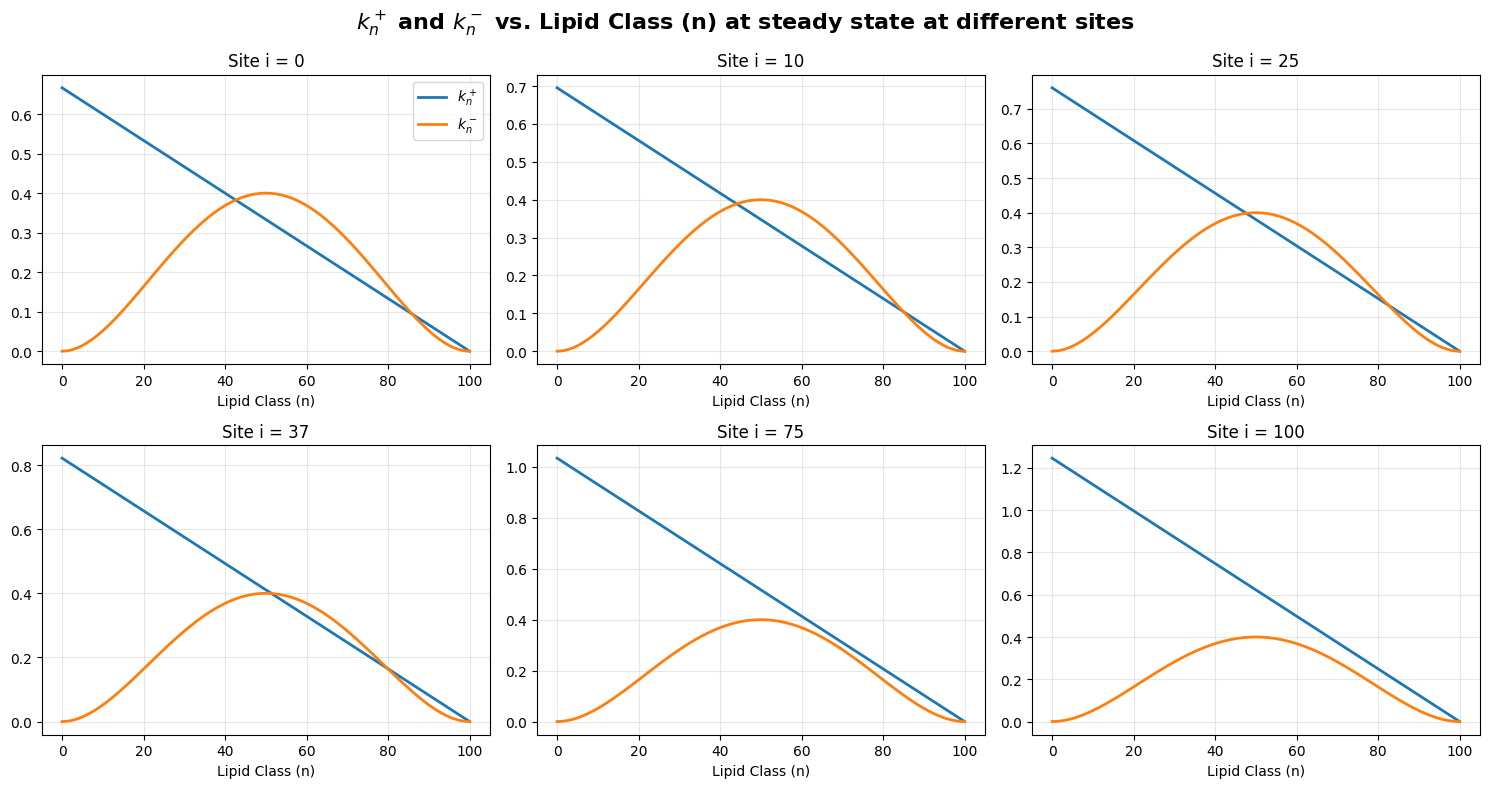

In [477]:
# Dynamically calculate grid size
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Loop through the sites and plot them
# Renamed 'idx' to 'plot_idx' to avoid the bug
for plot_idx, site in enumerate(spatial_sites_to_plot):
    ax = axes[plot_idx]
    
    # Ensure we don't ask for a site larger than the grid
    safe_site = min(site, p.M)

    # Calculate k^+_n
    k_plus_n = model.p.kplus * results["spatial"]["phi"][-1, safe_site] * model.n_decay
    k_minus_n = model.p.kminus * model.n_growth
 
    ax.plot(model.n_array, k_plus_n, label="$k^+_n$", linewidth=2)
    ax.plot(model.n_array, k_minus_n, label="$k^-_n$", linewidth=2)
        
    ax.set_title(f"Site i = {safe_site}")
    ax.set_xlabel("Lipid Class (n)")
    ax.grid(True, alpha=0.3)
    
    # Pro-tip: Only put the legend on the very first subplot so it isn't repeated 6 times!
    if plot_idx == 0:
        ax.legend()

# 4. Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("$k^+_n$ and $k^-_n$ vs. Lipid Class (n) at steady state at different sites", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

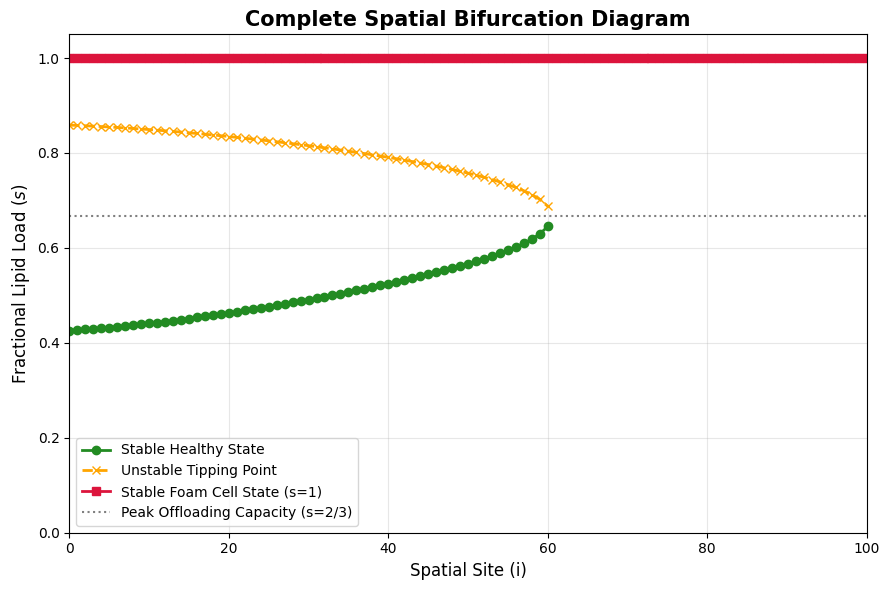

In [478]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

def find_all_steady_states(phi_i, p, offloading_type='quartic'):
    """
    Finds ALL biological equilibrium points (stable and unstable).
    Returns a sorted list of roots.
    """
    def net_velocity(s):
        uptake = phi_i * p.kplus * (1.0 - s)
        
        if offloading_type == 'linear':
            offloading = p.kminus * s
        elif offloading_type == 'quadratic':
            offloading = p.kminus * (s**2)
        elif offloading_type == 'parabolic':
            offloading = 4.0 * p.kminus * s * (1.0 - s)
        elif offloading_type == 'quartic':
            # Remember the 16.0 multiplier!
            offloading = 16.0 * p.kminus * (s**2) * ((1.0 - s)**2)
        else:
            raise ValueError("Unknown offloading type")
            
        return uptake - offloading

    # s = 1.0 is ALWAYS a steady state (uptake and offloading are both 0)
    roots = [1.0]

    # Evaluate the net velocity at the peak offloading capacity (s = 2/3)
    v_at_peak = net_velocity(2/3)
    
    # If V(2/3) < 0, the offloading curve is taller than the uptake curve.
    # This guarantees two additional intersections.
    if v_at_peak < 0:
        # 1. Find the stable healthy root (between 0 and 2/3)
        res_stable = root_scalar(net_velocity, bracket=[0.0, 2/3], method='brentq')
        if res_stable.converged:
            roots.append(res_stable.root)
            
        # 2. Find the unstable tipping point (between 2/3 and almost 1.0)
        # We use 0.99999 to avoid evaluating exactly at 1.0 where V=0
        if net_velocity(2/3) * net_velocity(0.99999) < 0:
            res_unstable = root_scalar(net_velocity, bracket=[2/3, 0.99999], method='brentq')
            if res_unstable.converged:
                roots.append(res_unstable.root)

    # Return the roots sorted from lowest to highest
    return sorted(roots)

def plot_full_bifurcation_diagram(model, U, time_index=-1, offloading_type='quartic'):
    """
    Plots the full spatial bifurcation diagram including stable and unstable branches.
    """
    p = model.p
    final_phi_profile = model.compute_phi(U[time_index])
    
    # Lists to hold the coordinates for our scatter plots
    stable_x, stable_y = [], []
    unstable_x, unstable_y = [], []
    foam_x, foam_y = [], []
    
    for i in range(p.M + 1):
        phi_i = final_phi_profile[i]
        roots = find_all_steady_states(phi_i, p, offloading_type)
        
        # If there are 3 roots, the system is Bistable
        if len(roots) == 3:
            stable_x.append(i);   stable_y.append(roots[0])
            unstable_x.append(i); unstable_y.append(roots[1])
            foam_x.append(i);     foam_y.append(roots[2])
            
        # If there is 1 root, the system is Monostable (Disease state)
        elif len(roots) == 1:
            foam_x.append(i);     foam_y.append(roots[0])

    # --- Plotting ---
    plt.figure(figsize=(9, 6))
    
    # Plot the branches
    plt.plot(stable_x, stable_y, marker='o', color='forestgreen', lw=2, label='Stable Healthy State')
    plt.plot(unstable_x, unstable_y, marker='x', color='orange', lw=2, linestyle='--', label='Unstable Tipping Point')
    plt.plot(foam_x, foam_y, marker='s', color='crimson', lw=2, label='Stable Foam Cell State (s=1)')
    
    # Formatting
    plt.title("Complete Spatial Bifurcation Diagram", fontsize=15, fontweight='bold')
    plt.xlabel("Spatial Site (i)", fontsize=12)
    plt.ylabel("Fractional Lipid Load ($s$)", fontsize=12)
    
    plt.ylim(0, 1.05)
    plt.xlim(0, p.M)
    plt.axhline(2/3, color='grey', linestyle=':', label='Peak Offloading Capacity (s=2/3)')
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_full_bifurcation_diagram(model, U, time_index=-1, offloading_type='quartic')

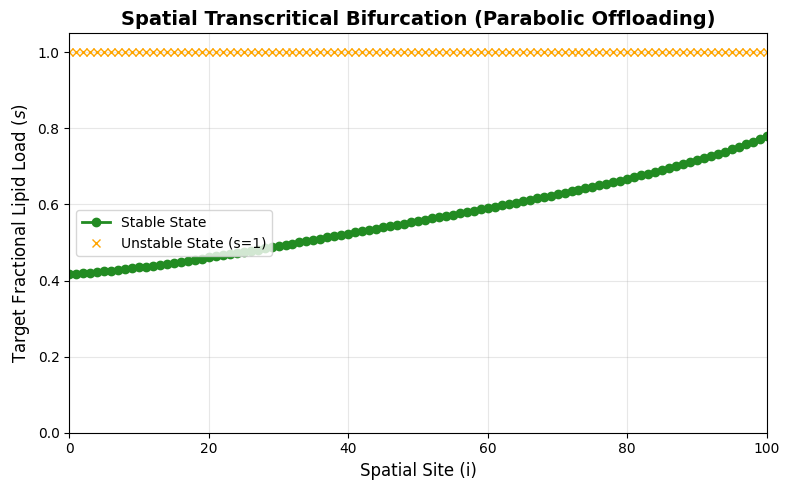

In [479]:
import numpy as np
import matplotlib.pyplot as plt

def plot_transcritical_bifurcation(model, U, time_index=-1):
    """
    Plots the Transcritical Bifurcation using the exact algebraic solution 
    for the Parabolic offloading curve.
    """
    p = model.p
    final_phi_profile = model.compute_phi(U[time_index])
    
    sites = np.arange(p.M + 1)
    stable_branch = np.zeros(p.M + 1)
    unstable_branch = np.zeros(p.M + 1)
    
    for i in sites:
        phi_i = final_phi_profile[i]
        
        # Calculate the theoretical interior root
        s_interior = (phi_i * p.kplus) / (4.0 * p.kminus)
        
        if s_interior < 1.0:
            # Healthy Zone: Interior root is stable, s=1 is unstable
            stable_branch[i] = s_interior
            unstable_branch[i] = 1.0
        else:
            # Foam Cell Zone: s=1 is stable, Interior root is non-physical
            stable_branch[i] = 1.0
            unstable_branch[i] = np.nan # Hide the non-physical root
            
    # --- Plotting ---
    plt.figure(figsize=(8, 5))
    
    # Plot the stable states
    plt.plot(sites, stable_branch, marker='o', color='forestgreen', lw=2, label='Stable State')
    
    # Plot the unstable states (s=1 for healthy sites)
    plt.plot(sites, unstable_branch, marker='x', color='orange', lw=2, linestyle='', label='Unstable State (s=1)')
    
    plt.title("Spatial Transcritical Bifurcation (Parabolic Offloading)", fontsize=14, fontweight='bold')
    plt.xlabel("Spatial Site (i)", fontsize=12)
    plt.ylabel("Target Fractional Lipid Load ($s$)", fontsize=12)
    
    plt.ylim(0, 1.05)
    plt.xlim(0, p.M)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='center left')
    plt.tight_layout()
    plt.show()

plot_transcritical_bifurcation(model, U, time_index=-1)

#### Spatial profiles

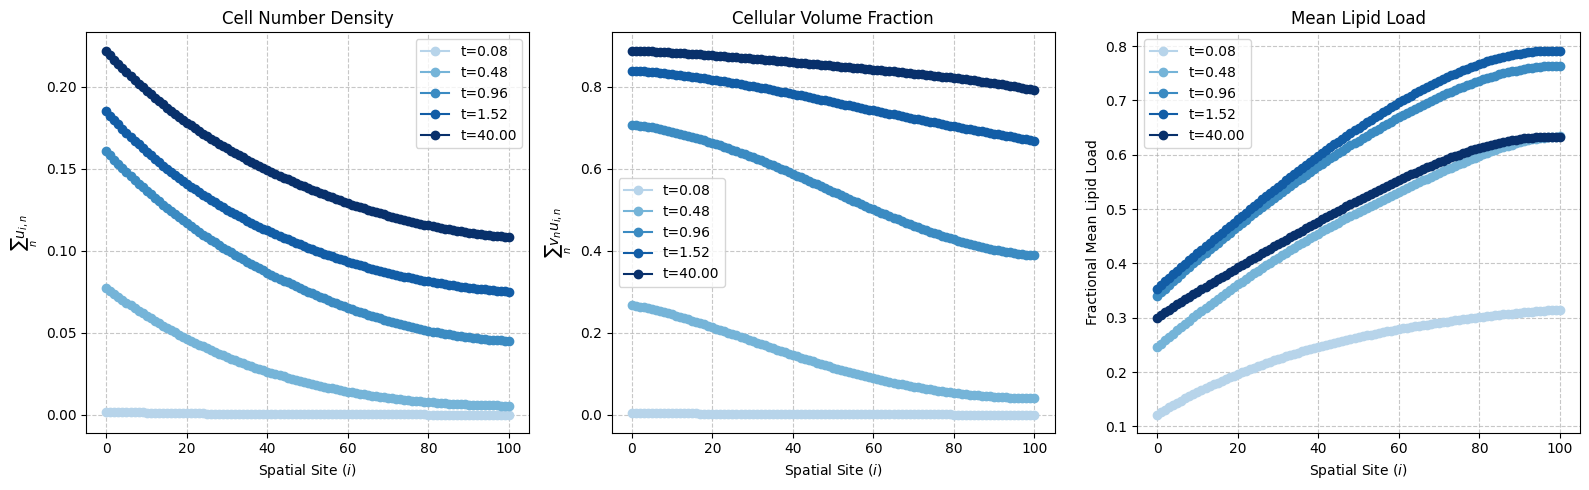

In [480]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3. Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    
    # Add the 'color=c' argument to your plots
    axes[1].plot(model.i_array, results["spatial"]["volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[0].plot(model.i_array, results["spatial"]["cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[2].plot(model.i_array, results["spatial"]["mean_lipid_load"][idx, :]/model.p.N, 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)

# Format the plots
axes[1].set_title("Cellular Volume Fraction")
axes[1].set_xlabel("Spatial Site ($i$)")
axes[1].set_ylabel(r"$\sum_n v_n u_{i,n}$")

axes[0].set_title("Cell Number Density")
axes[0].set_xlabel("Spatial Site ($i$)")
axes[0].set_ylabel(r"$\sum_n u_{i,n}$")

axes[2].set_title("Mean Lipid Load")
axes[2].set_xlabel("Spatial Site ($i$)")
axes[2].set_ylabel("Fractional Mean Lipid Load")

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Structure profiles

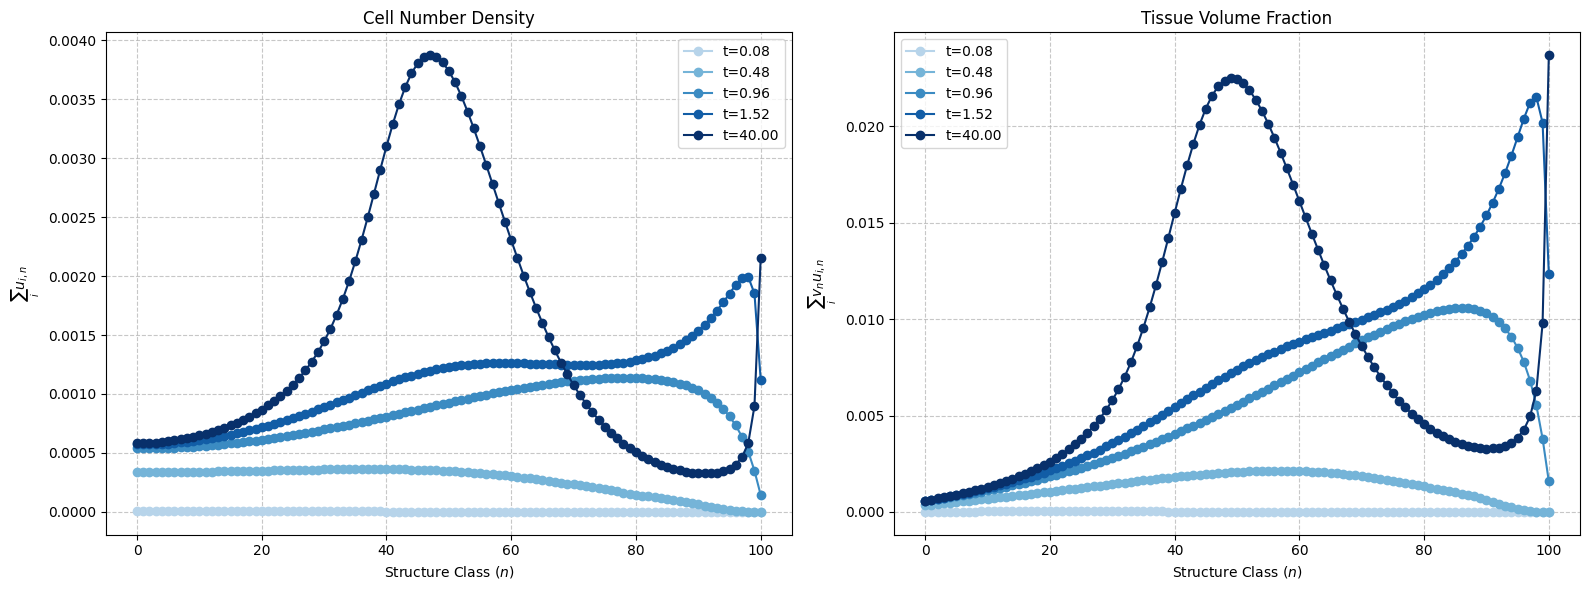

In [481]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    
    # Add the 'color=c' argument to your plots
    axes[0].plot(model.n_array, results["structure"]["average_cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[1].plot(model.n_array, results["structure"]["tissue_volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)

# Format the plots
axes[0].set_title("Cell Number Density")
axes[0].set_xlabel("Structure Class ($n$)")
axes[0].set_ylabel(r"$\sum_i u_{i,n}$")

axes[1].set_title("Tissue Volume Fraction")
axes[1].set_xlabel("Structure Class ($n$)")
axes[1].set_ylabel(r"$\sum_i v_n u_{i,n}$")

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

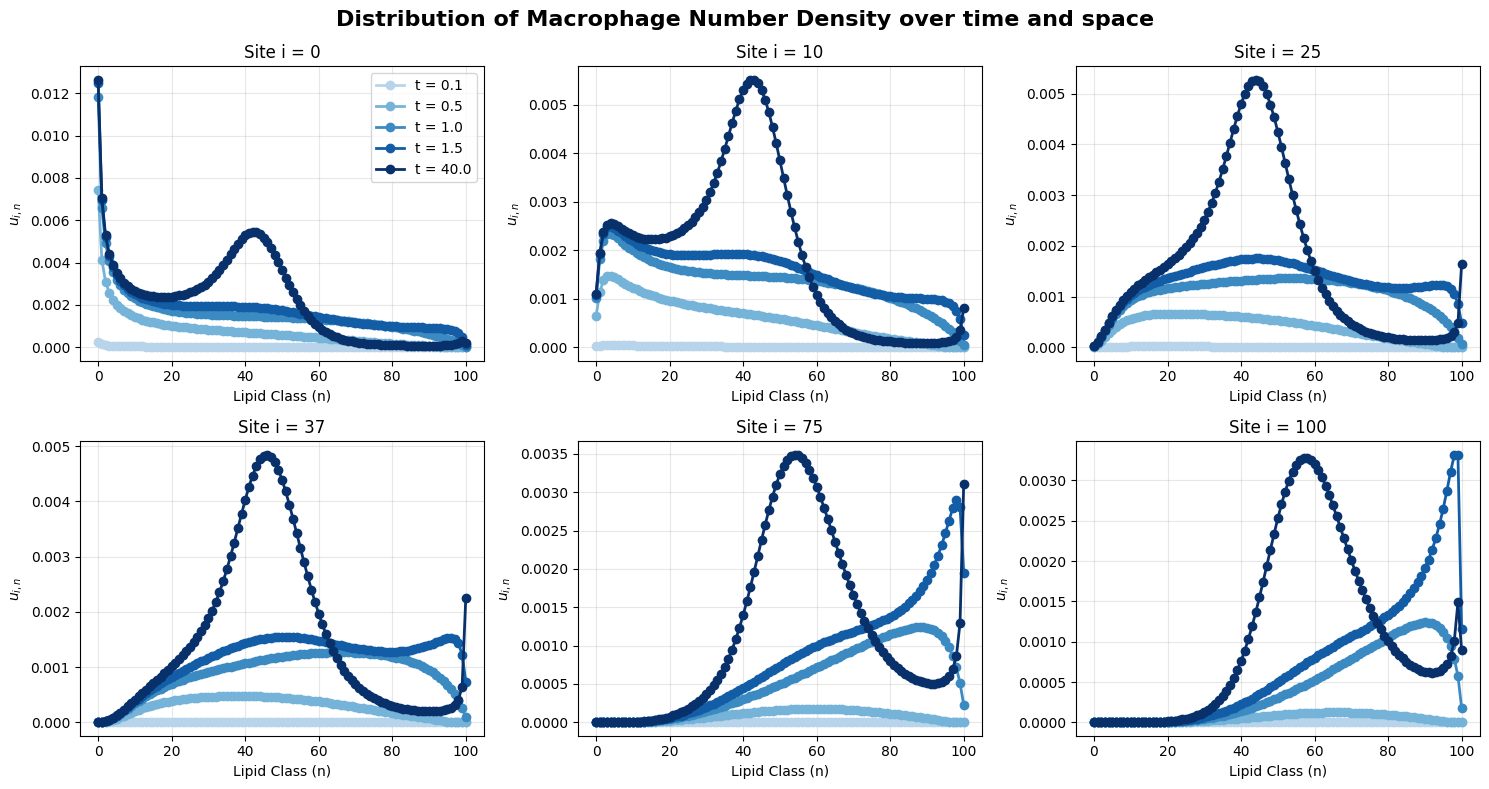

In [485]:
# Dynamically calculate grid size
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Loop through the sites and plot them
# Renamed 'idx' to 'plot_idx' to avoid the bug
for plot_idx, site in enumerate(spatial_sites_to_plot):
    ax = axes[plot_idx]
    
    # Ensure we don't ask for a site larger than the grid
    safe_site = min(site, p.M)

    # Use 'enumerate' to get 'j' so we can pick the matching color
    for j, target_t in enumerate(time_points):
        
        # Renamed the time index to 't_idx' so it doesn't break the outer loop
        t_idx = np.argmin(np.abs(sol.t - target_t))
        actual_t = sol.t[t_idx]
        
        # Grab the specific color for this line
        c = colors[j]
    
        ax.plot(model.n_array, U[t_idx, safe_site, :] , 
                label=f"t = {actual_t:.1f}", linewidth=2, marker='o', color=c)
        
    ax.set_title(f"Site i = {safe_site}")
    ax.set_xlabel("Lipid Class (n)")
    ax.set_ylabel(r"$u_{i,n}$")
    ax.grid(True, alpha=0.3)
    
    # Pro-tip: Only put the legend on the very first subplot so it isn't repeated 6 times!
    if plot_idx == 0:
        ax.legend()

# 4. Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Distribution of Macrophage Number Density over time and space", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Total profiles

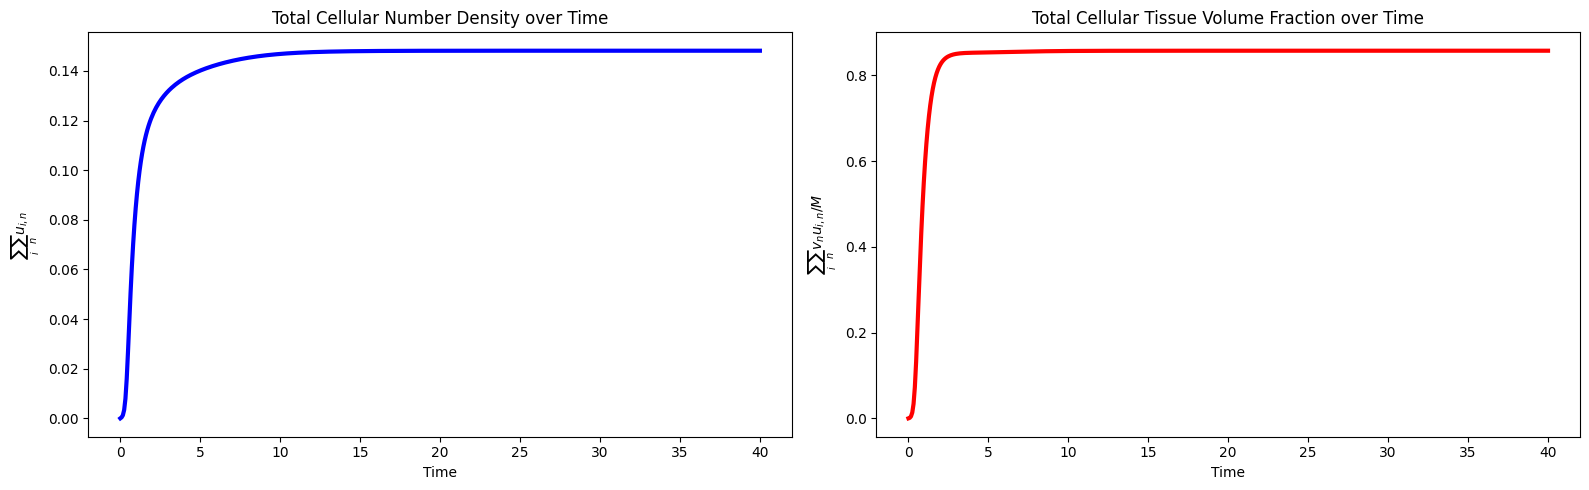

In [483]:
# Plot total cell density and tissue volume fraction over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sol.t, results["totals"]["average_cell_density"], linewidth=3, color='blue')
axes[0].set_title("Total Cellular Number Density over Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$\sum_i\sum_n u_{i,n}$ ")

axes[1].plot(sol.t, results["totals"]["tissue_volume_fraction"], linewidth=3, color='red')
axes[1].set_title("Total Cellular Tissue Volume Fraction over Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$\sum_i\sum_n v_n u_{i,n}/M$ ")

for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

#### Heatmaps

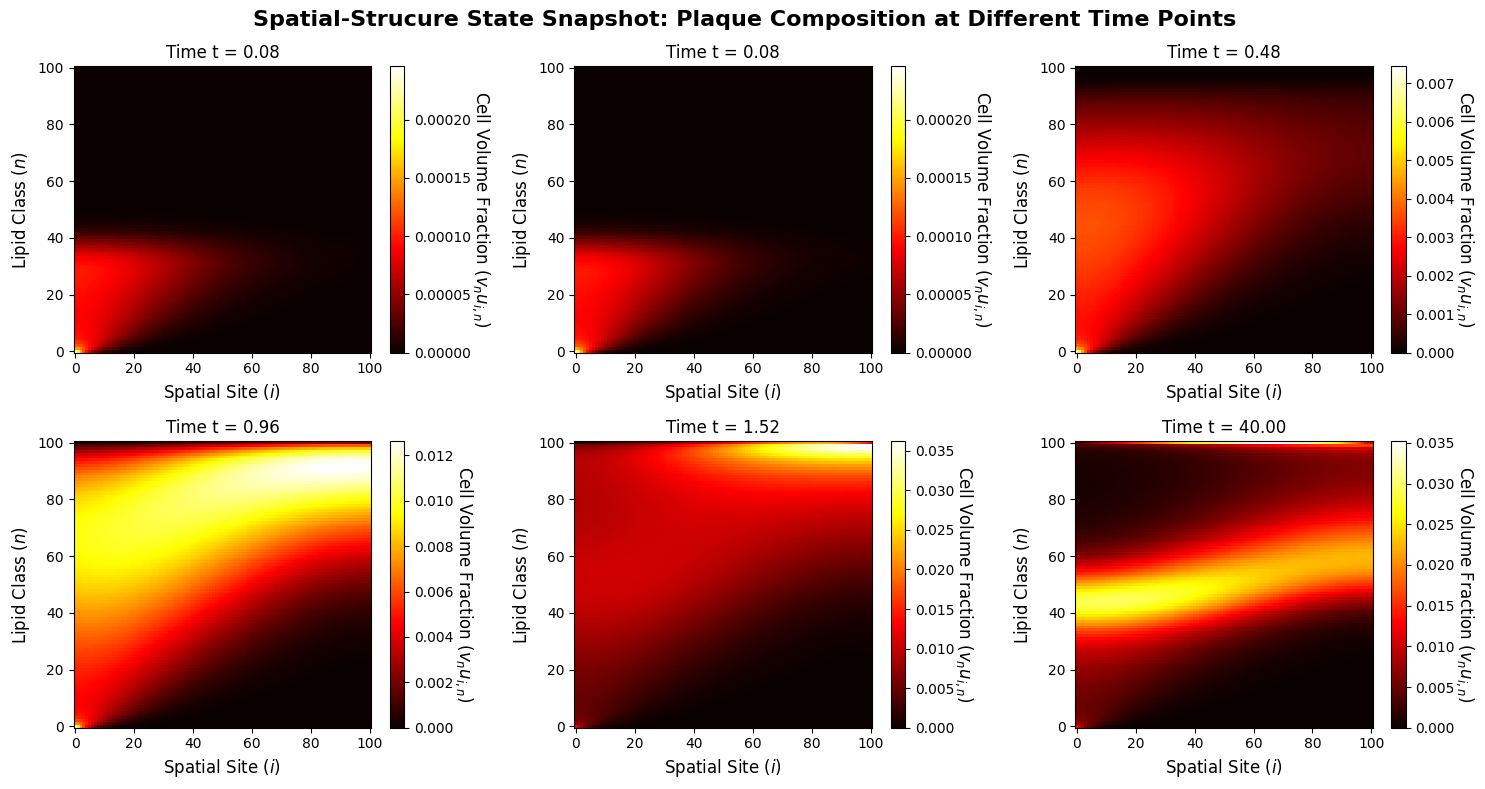

In [484]:
# Plot the heatmap of the local macrophage volume fraction at different time points
time_points_heatmap = [0.05, 0.1, 0.5, 1.0, 1.5, t_final]

num_plots = len(time_points_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    mesh = ax.pcolormesh(model.i_array, model.n_array, (U[idx, :, :] * model.v).T,
                     cmap='hot', shading='auto') # hot, OrRd, Reds

    # Add the Colorbar so we can read the values
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Cell Volume Fraction ($v_n u_{i,n}$)", rotation=270, labelpad=15, fontsize=12)

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Spatial Site ($i$)", fontsize=12)
    ax.set_ylabel("Lipid Class ($n$)", fontsize=12)

    #ax.set_xlim(0, 6)
    #ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Spatial-Strucure State Snapshot: Plaque Composition at Different Time Points", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()